In [1]:
  %reload_ext autoreload
%autoreload 2

import re
import time
import torch.nn as nn
import torch.nn.functional as F
import torch
import numpy as np
import pandas as pd
from torch.utils.data import random_split
from monty.serialization import loadfn
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import KFold
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from tensorflow.keras.preprocessing.sequence import pad_sequences

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/qfu1/.local/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-12 15:34:14.004864: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-12 15:34:14.015169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741818854.026703   23279 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0

In [2]:
data_path = "representation_data5k.csv"
entries = loadfn("Test Crystring Package/data/MP_data-10000-20000.json.gz")
MPdata = pd.read_csv(data_path)

In [3]:
import json
with open('RandomGenDATA.json', 'r') as f:
    RandomGenDATA = json.load(f)

REPRESENTATION = [RandomGenDATA[f'{idx}']['REPRESENTATION'] for idx in range(len(RandomGenDATA.keys()))]
PARAMS = [[0, 0, 0, 0, 0, 0] for _ in range(len(REPRESENTATION))]

In [4]:
lattice_params = []
for id in MPdata["id"]:
    entry = entries[id]
    structure = SpacegroupAnalyzer(entries[id]["structure"],symprec=5e-1)
    lattice = structure.get_conventional_standard_structure().lattice
    lattice_params.append([lattice.a, lattice.b, lattice.c, lattice.alpha, lattice.beta, lattice.gamma])
MPdata["lattice_params"] = lattice_params

REPRESENTATION.extend(MPdata['string'])
PARAMS.extend(MPdata['lattice_params'])

In [5]:
df = pd.DataFrame({"string": REPRESENTATION, "lattice_params": PARAMS})

In [6]:
def process_string(s):
    tokens = s.split()
    tokens.insert(0, "START")
    tokens.append("END")
    return tokens

In [7]:
def split_float_values(token_list):
    new_tokens = []
    for token in token_list:
        if re.match(r'^\d+\.\d+$', token):
            new_tokens.extend(list(token.replace('0.', '')))
        else:
            new_tokens.append(token)
    return new_tokens

In [8]:
df['tokens'] = df['string'].apply(process_string)
df['tokens'] = df['tokens'].apply(split_float_values)
df['tokens'].head()

0    [START, I, 21, 3, 1, Mo, 24c, 9, 5, 7, 3, 9, 5...
1    [START, P, 31, 1, 2, Tc, 6c, 8, 0, 5, 7, 6, 5,...
2    [START, P, c, c, m, Be, 2d, 0, 0, 0, 0, 0, 0, ...
3    [START, P, 63/m, c, m, Nb, 6g, 7, 8, 2, 0, 0, ...
4    [START, F, 4bar, 3, m, Pb, 4b, 0, 0, 0, 0, 0, ...
Name: tokens, dtype: object

In [9]:
def VocabDict(data):
    segment1_list = []
    segment2_list = []
    
    for tokens in data:
        segment1 = tokens[1:5] # spacegroup
        segment2 = tokens[5:] # wyckoff info
        segment2.insert(0, tokens[0])
        
        segment1_list.extend([f's1_{token}' for token in segment1])
        segment2_list.extend([f's2_{token}' for token in segment2])
    
    counter1 = Counter(segment1_list)
    counter2 = Counter(segment2_list)
    combined_counter = counter1 + counter2
    combined_items = combined_counter.most_common()
    token_to_number_combined = {token: i+1 for i, (token, _) in enumerate(combined_items)}
    number_to_token_combined = dict(zip(token_to_number_combined.values(), token_to_number_combined.keys()))
    return token_to_number_combined, number_to_token_combined

In [10]:
token_to_number_combined, number_to_token_combined = VocabDict(df['tokens'])

In [11]:
def tokenize_string(tokens):
    segment1 = tokens[1:5]
    segment2 = tokens[5:]
    
    tokenized_segment1 = [token_to_number_combined["s1_"+token] for token in segment1]
    tokenized_segment2 = [token_to_number_combined["s2_"+token] for token in segment2]
    
    return [token_to_number_combined["s2_"+tokens[0]]] + tokenized_segment1 + tokenized_segment2

In [12]:
df['tokenized'] = df['tokens'].apply(tokenize_string)

In [13]:
from sklearn.preprocessing import MinMaxScaler
max_sequence_len = max([len(seq) for seq in df['tokenized']])
X = np.array(pad_sequences(df['tokenized'], maxlen=max_sequence_len, padding="pre"))
y = np.array([i for i in df["lattice_params"]])

test_X = torch.tensor(X[:30], dtype=torch.long)
test_y = torch.tensor(y[:30], dtype=torch.float)

remaining_X = torch.tensor(X[30:], dtype=torch.long)
remaining_Y = torch.tensor(y[30:], dtype=torch.float)

print(test_X.shape, remaining_X.shape)
print(test_y.shape, remaining_Y.shape)

torch.Size([30, 613]) torch.Size([5101, 613])
torch.Size([30, 6]) torch.Size([5101, 6])


In [14]:
max_length = max_sequence_len
vocab_size = len(token_to_number_combined)+1
emb_dim = 64
hidden_size = 128
batch_size=512

In [15]:
train_size = int(0.8 * len(remaining_X))
test_size = len(remaining_X) - train_size
test_dataset2 = TensorDataset(test_X, test_y)
dataset = TensorDataset(remaining_X, remaining_Y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True)

In [41]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(LSTMModel, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(in_features=hidden_size, out_features=512),
                nn.SiLU(),
                nn.Linear(in_features=512, out_features=128),
                nn.SiLU(),
                nn.Linear(in_features=128, out_features=1)
            )
            for _ in range(6)
        ])

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        embedding = self.embedding_layer(x)
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        last_output = rnn_output[:, -1, :]
        # torch.Size([batch_size, hidden_size])
        outputs = [fc(last_output) for fc in self.fc_layers]
        final_output = torch.cat(outputs, dim=1)
        # torch.Size([batch_size, 6])
        return final_output

In [42]:
def kfold_trian(dataset, kf, model, criterion, optimizer, epochs, batch_size, mute=False):
    TrainLoss = []
    ValLoss = []
    model.to(device)
    start_time = time.time()
    
    for epoch in range(epochs):
        total_train_loss = 0
        total_val_loss = 0
    
        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            model.train()
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    
            # Training phase
            fold_train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                optimizer.zero_grad()                
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                fold_train_loss += loss.item()
            total_train_loss += fold_train_loss / len(train_loader)
    
            # Validation phase
            model.eval()
            fold_val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X = batch_X.to(device)
                    batch_y = batch_y.to(device)
                    predictions = model(batch_X)
                    loss = criterion(predictions, batch_y)
                    fold_val_loss += loss.item()
                    
            total_val_loss += fold_val_loss / len(val_loader)
            
        if not mute:
            if (epoch + 1) % 10 == 0:
                end_time = time.time()
                training_time = end_time - start_time
                avg_train_loss = total_train_loss / num_folds
                avg_val_loss = total_val_loss / num_folds
                print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {training_time:.2f}')
            
        if (epoch + 1) % 1 == 0:
            TrainLoss.append(total_train_loss / num_folds)
            ValLoss.append(total_val_loss / num_folds)
            
    return model, TrainLoss, ValLoss

In [43]:
lr=5e-3
wd=1e-5
epochs = 300
num_layers = 1

In [44]:
model = LSTMModel(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
model, TrainLoss, ValLoss = kfold_trian(train_dataset, kf, model, criterion, optimizer, epochs, batch_size)

Epoch [10/300] - Train Loss: 40.6343, Val Loss: 40.0936, Time: 11.37
Epoch [20/300] - Train Loss: 40.2539, Val Loss: 39.9410, Time: 23.17
Epoch [30/300] - Train Loss: 39.5758, Val Loss: 39.8850, Time: 34.64
Epoch [40/300] - Train Loss: 38.5871, Val Loss: 38.6283, Time: 46.49
Epoch [50/300] - Train Loss: 38.9733, Val Loss: 38.7259, Time: 58.14
Epoch [60/300] - Train Loss: 36.2580, Val Loss: 35.7343, Time: 69.87
Epoch [70/300] - Train Loss: 12.7280, Val Loss: 12.8842, Time: 82.03
Epoch [80/300] - Train Loss: 8.5683, Val Loss: 8.6640, Time: 93.95
Epoch [90/300] - Train Loss: 7.3317, Val Loss: 7.7738, Time: 106.24
Epoch [100/300] - Train Loss: 5.3204, Val Loss: 5.4344, Time: 118.21
Epoch [110/300] - Train Loss: 3.9782, Val Loss: 3.9758, Time: 130.21
Epoch [120/300] - Train Loss: 3.3970, Val Loss: 3.5129, Time: 142.53
Epoch [130/300] - Train Loss: 2.4134, Val Loss: 2.3887, Time: 154.54
Epoch [140/300] - Train Loss: 1.7670, Val Loss: 1.8443, Time: 166.87
Epoch [150/300] - Train Loss: 1.5280,

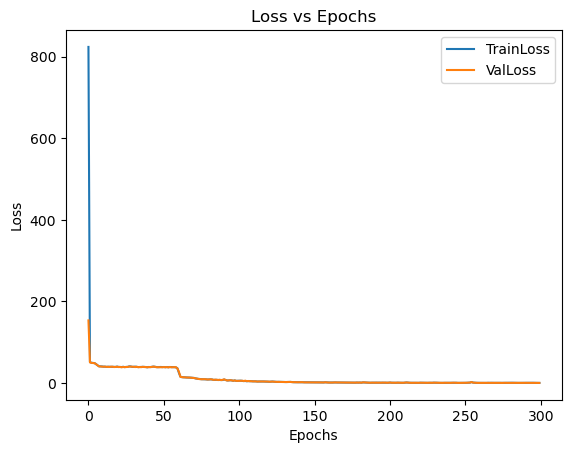

In [45]:
plt.plot(TrainLoss, label="TrainLoss")
plt.plot(ValLoss, label="ValLoss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

In [46]:
all_predictions = []
all_true_outputs = []
model.eval()
with torch.no_grad():
    for Input, TrueOutput in test_dataset:
        Input = Input.to(device)
        
        PredictedOutput = model(Input.unsqueeze(0))
        
        all_predictions.append(PredictedOutput[0].cpu())
        all_true_outputs.append(TrueOutput)

all_true_outputs = torch.tensor(np.array(all_true_outputs))
all_predictions = torch.tensor(np.array(all_predictions))

Test Results: 
Saved plot as pic/plot_A_length.png


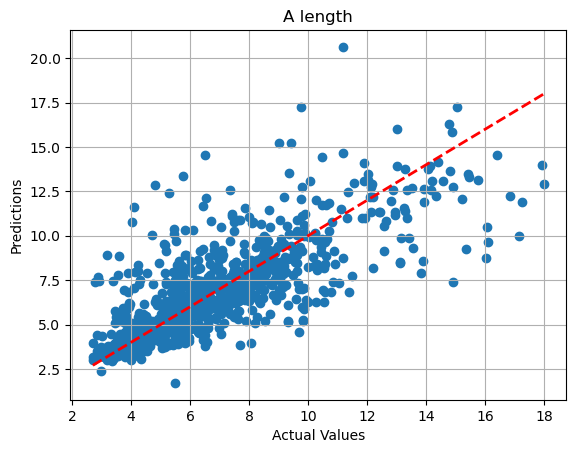

Score Metrics:
Total MSE: 3.18
Total MAE: 1.15
Total R²: 0.58

Saved plot as pic/plot_B_length.png


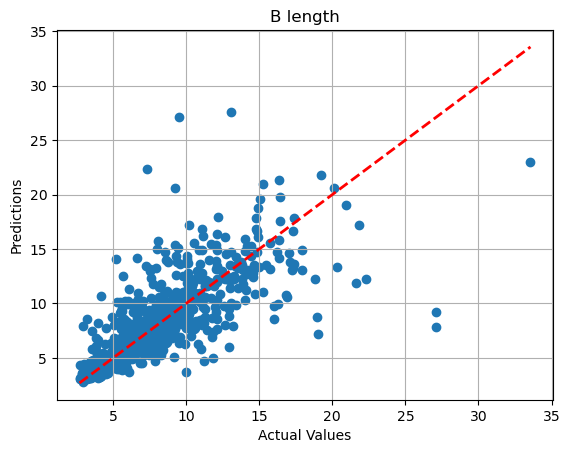

Score Metrics:
Total MSE: 5.54
Total MAE: 1.32
Total R²: 0.55

Saved plot as pic/plot_C_length.png


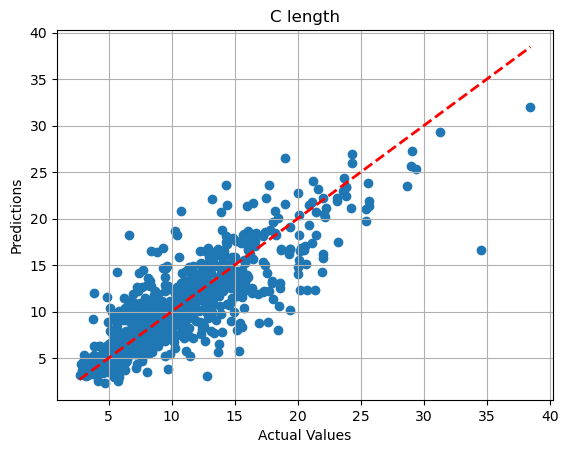

Score Metrics:
Total MSE: 6.41
Total MAE: 1.65
Total R²: 0.74

Saved plot as pic/plot_Alpha.png


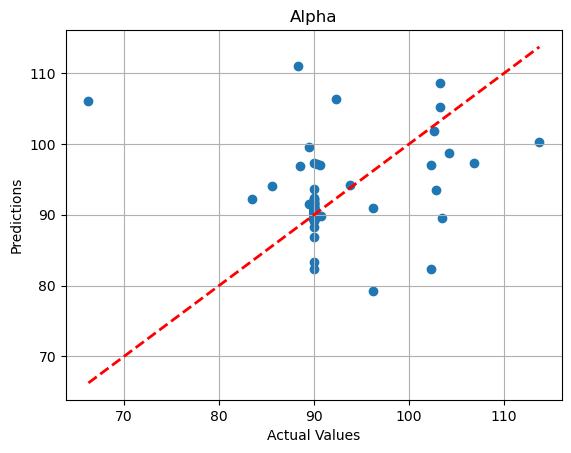

Score Metrics:
Total MSE: 4.21
Total MAE: 0.41
Total R²: -0.48

Saved plot as pic/plot_Beta.png


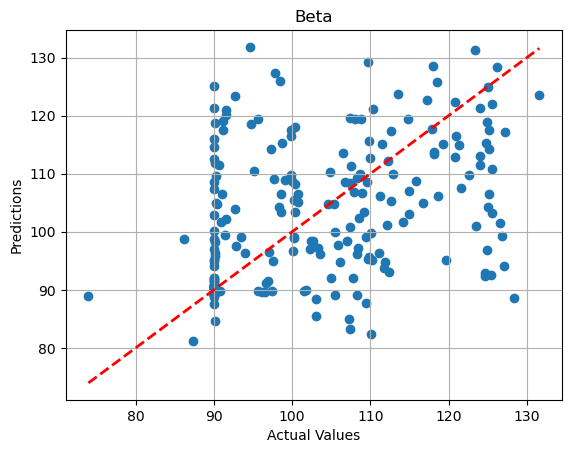

Score Metrics:
Total MSE: 40.33
Total MAE: 2.31
Total R²: 0.37

Saved plot as pic/plot_Gamma.png


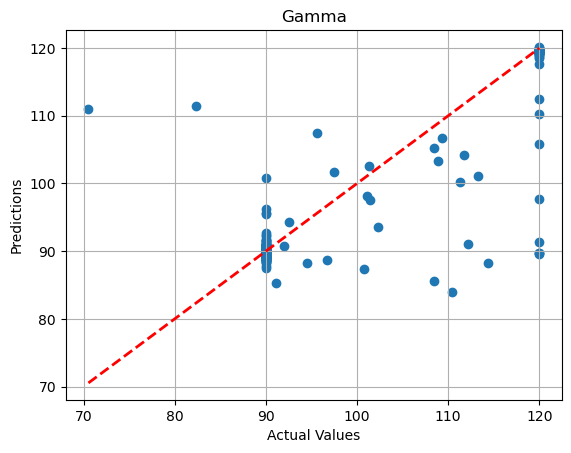

Score Metrics:
Total MSE: 10.39
Total MAE: 0.79
Total R²: 0.94



In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Test Results: ")
titles = ["A length", "B length", "C length", "Alpha", "Beta", "Gamma"]
for i in range(6):
    mse_total = mean_squared_error(all_true_outputs[:, i], all_predictions[:, i])
    mae_total = mean_absolute_error(all_true_outputs[:, i], all_predictions[:, i])
    r2_total = r2_score(all_true_outputs[:, i], all_predictions[:, i])

    plt.scatter(all_true_outputs[:, i], all_predictions[:, i], label='Test Samples')
    plt.plot([min(all_true_outputs[:, i]), max(all_true_outputs[:, i])], [min(all_true_outputs[:, i]), max(all_true_outputs[:, i])],
             color='red', linestyle='--', linewidth=2)
    plt.title(titles[i])
    plt.ylabel("Predictions")
    plt.xlabel("Actual Values")
    
    filename = f"pic/plot_{titles[i].replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)  # Save each plot with a descriptive name
    plt.grid()
    print(f"Saved plot as {filename}")
    plt.show()

    
    print("Score Metrics:")
    print(f"Total MSE: {mse_total:.2f}")
    print(f"Total MAE: {mae_total:.2f}")
    print(f"Total R²: {r2_total:.2f}\n")


In [23]:
mse_total = mean_squared_error(all_true_outputs, all_predictions)
mae_total = mean_absolute_error(all_true_outputs, all_predictions)
r2_total = r2_score(all_true_outputs, all_predictions)

print("Score Metrics:")
print("Total MSE:", mse_total)
print("Total MAE:", mae_total)
print("Total R²:", r2_total)

Score Metrics:
Total MSE: 11.462646
Total MAE: 1.2752992
Total R²: 0.5032822539822887


In [24]:
for i, j in zip(all_predictions, all_true_outputs):
    print(f"prediction: {i.tolist()}")
    print(f"True: {j.tolist()}")
    print()

prediction: [5.868551254272461, 5.998305797576904, 3.8977668285369873, 90.08354187011719, 90.35611724853516, 119.68592071533203]
True: [6.549349784851074, 6.549349784851074, 3.610196113586426, 90.0, 90.0, 120.0]

prediction: [5.448461055755615, 5.797976493835449, 7.177323818206787, 90.08840942382812, 90.42320251464844, 90.41500091552734]
True: [4.319823265075684, 6.7178635597229, 6.978252410888672, 90.0, 90.0, 90.0]

prediction: [3.4882493019104004, 3.7827625274658203, 25.435749053955078, 90.10958099365234, 90.4542465209961, 119.89515686035156]
True: [4.090330123901367, 4.090330123901367, 21.980621337890625, 90.0, 90.0, 120.0]

prediction: [4.522139072418213, 4.345866680145264, 5.395577907562256, 90.05039978027344, 90.42879486083984, 90.04548645019531]
True: [4.409191608428955, 4.409191608428955, 2.913888454437256, 90.0, 90.0, 90.0]

prediction: [10.01121997833252, 15.642925262451172, 8.710278511047363, 89.97489166259766, 89.9300765991211, 88.7519760131836]
True: [13.836483001708984, 6

In [25]:
def enter_params(parameters: list) -> np.ndarray:
    params = {
        "a": 0,
        "b": 0,
        "c": 0,
        "alpha": 90,
        "beta": 90,
        "gamma": 90,
    }
    for item in parameters:
        params[item] = item
        if "b" not in parameters:
            params["b"] = params["a"]
        if "c" not in parameters:
            params["c"] = params["a"]
    return np.array(list(params.values()))

In [26]:
from crystring.spacegroup import get_cell_param_from_spacegroup

In [27]:
model.eval()
with torch.no_grad():
    i = 0
    for Input, _ in test_dataset2:
        Input = Input.to(device)
        PredictedOutput = model(Input.unsqueeze(0))
        # PredictedOutput = scaler.inverse_transform(PredictedOutput.cpu())
        SGNumber = RandomGenDATA[f'{i}']['SPACEGROUPNUMBER']
        print(SGNumber, " ".join(RandomGenDATA[f'{i}']['REPRESENTATION'].split()[:4]))
        # print(SGNumber, get_cell_param_from_spacegroup(SGNumber))
        i+=1
        print(PredictedOutput[0].cpu().tolist())

199 I 21 3 1
[6.1782989501953125, 8.785197257995605, 8.228446006774902, 90.54666137695312, 90.385986328125, 90.37065124511719]
151 P 31 1 2
[4.476787090301514, 4.179821491241455, 7.923482418060303, 90.50492858886719, 90.16992950439453, 120.36416625976562]
49 P c c m
[4.250349044799805, 3.865851879119873, 6.299312114715576, 90.37089538574219, 90.19190979003906, 120.33023071289062]
193 P 63/m c m
[5.69291877746582, 5.552746295928955, 3.5098400115966797, 90.44476318359375, 90.40242004394531, 120.5569076538086]
216 F 4bar 3 m
[7.740996360778809, 7.661116123199463, 6.250130653381348, 90.49346923828125, 90.42427062988281, 90.57147216796875]
26 P m c 21
[7.346278667449951, 6.648498058319092, 6.236911296844482, 87.80787658691406, 87.69019317626953, 116.27266693115234]
132 P 42/m c m
[5.726681709289551, 5.6441192626953125, 6.633498668670654, 90.59561157226562, 90.2061996459961, 90.51615142822266]
104 P 4 n c
[5.856524467468262, 5.828912258148193, 5.535961627960205, 90.42060852050781, 90.1124801